# White Encoding Valence Analysis — GPT-2, Layer 6

**Phase 4:** Three-comparison valence analysis at layer 6 (White-Black, White-Hispanic, Hispanic-Black).

Produces Figure 7 from the paper.

**Hardware:** M4 Mac Mini or any GPU  
**Runtime:** ~3 minutes  
**Run all cells top to bottom.**

**Output:** `white_encoding_valence_layer6.png`


In [1]:
# Configuration
PKL_PATH = '/content/drive/MyDrive/ID-UTH-repo/results/white_encoding_results.pkl'
OUTPUT_DIR = '/content/drive/MyDrive/ID-UTH-repo/results/valence'
LAYER = 6
TOP_K = 10

import os
from google.colab import drive
try:
    drive.mount('/content/drive')
except ValueError:
    pass
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config ready.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config ready.


In [2]:
!pip install -q numpy==1.26.4
!pip install -q transformer_lens

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from transformer_lens import HookedTransformer
print('Ready.')


Ready.


In [3]:
# Load activations
with open(PKL_PATH, 'rb') as f:
    raw = pickle.load(f)

group_records = raw['group_records']
print('Groups:', list(group_records.keys()))

# Extract layer 6 activations for all three groups
key = f'layer_{LAYER}'
white_acts    = np.array([r[key] for r in group_records['White']])
black_acts    = np.array([r[key] for r in group_records['Black']])
hispanic_acts = np.array([r[key] for r in group_records['Hispanic']])

print(f'White: {white_acts.shape}, Black: {black_acts.shape}, Hispanic: {hispanic_acts.shape}')


Groups: ['White', 'Black', 'Hispanic']
White: (48, 768), Black: (48, 768), Hispanic: (48, 768)


In [4]:
# Load GPT-2 embedding matrix
print('Loading GPT-2...')
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
gpt2 = HookedTransformer.from_pretrained('gpt2', device=DEVICE)
gpt2.eval()

W_E = gpt2.embed.W_E.detach().cpu().numpy()
tokenizer = gpt2.tokenizer
vocab = [tokenizer.decode([i]).strip() for i in range(W_E.shape[0])]
print(f'W_E shape: {W_E.shape}')

del gpt2
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Model freed.')


Loading GPT-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
W_E shape: (50257, 768)
Model freed.


In [5]:
# Three-comparison valence at layer 6
def dom_direction(acts_a, acts_b):
    d = acts_a.mean(axis=0) - acts_b.mean(axis=0)
    return d / (np.linalg.norm(d) + 1e-8)

def project_vocab(direction, W_E, vocab, top_k=TOP_K):
    norms = np.linalg.norm(W_E, axis=1, keepdims=True) + 1e-8
    scores = (W_E / norms) @ direction
    top_idx = np.argsort(scores)[::-1][:top_k]
    bot_idx = np.argsort(scores)[:top_k]
    return [(vocab[i], float(scores[i])) for i in top_idx], \
           [(vocab[i], float(scores[i])) for i in bot_idx]

comparisons = {
    'White − Black':    (white_acts,    black_acts,    'White', 'Black',    '#2D6A4F', '#4472C4'),
    'White − Hispanic': (white_acts,    hispanic_acts, 'White', 'Hispanic', '#2D6A4F', '#ED7D31'),
    'Hispanic − Black': (hispanic_acts, black_acts,    'Hispanic', 'Black', '#ED7D31', '#4472C4'),
}

results = {}
for name, (acts_a, acts_b, label_a, label_b, color_a, color_b) in comparisons.items():
    direction = dom_direction(acts_a, acts_b)
    top, bot = project_vocab(direction, W_E, vocab)
    results[name] = {'top': top, 'bottom': bot,
                     'label_a': label_a, 'label_b': label_b,
                     'color_a': color_a, 'color_b': color_b}
    print(f'{name}:')
    print(f'  {label_a} pole: {[t for t,s in top[:5]]}')
    print(f'  {label_b} pole: {[t for t,s in bot[:5]]}')
    print()


White − Black:
  White pole: ['aukee', 'bilt', 'State', 'insula', 'ablishment']
  Black pole: ['any', 'strap', 'smith', 'ened', 'trace']

White − Hispanic:
  White pole: ['Plains', 'hurst', 'haven', 'house', 'horse']
  Hispanic pole: ['ity', 'detention', 'ities', 'ITIES', 'joints']

Hispanic − Black:
  Hispanic pole: ['Gast', 'Gomez', 'Cruz', 'bilingual', 'Gutierrez']
  Black pole: ['feet', 'bird', 'foot', 'birds', 'adder']



Saved: /content/drive/MyDrive/ID-UTH-repo/results/valence/white_encoding_valence_layer6.png


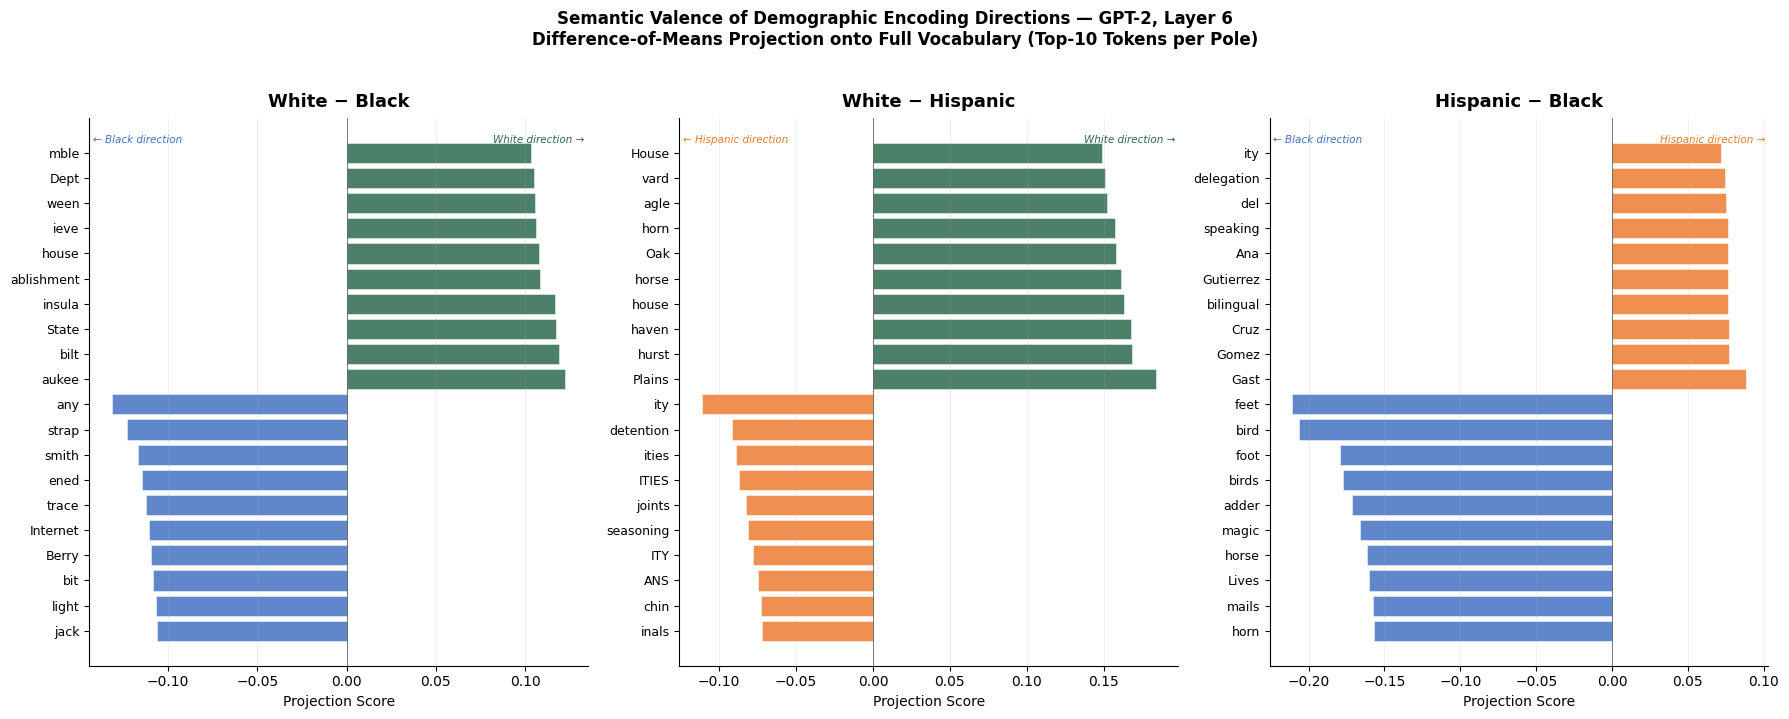

In [6]:
# Figure 7 — three-panel comparison at layer 6
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (name, res) in zip(axes, results.items()):
    top = res['top']
    bot = res['bottom']
    all_items = list(reversed(bot)) + list(top)
    labels = [t for t, s in all_items]
    scores = [s for t, s in all_items]
    colors = [res['color_b'] if s < 0 else res['color_a'] for s in scores]

    y_pos = range(len(all_items))
    ax.barh(y_pos, scores, color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.7, alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Projection Score', fontsize=10)
    ax.set_title(name, fontsize=13, fontweight='bold', pad=8)
    ax.grid(axis='x', alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xlim = ax.get_xlim()
    ax.text(xlim[0]+0.002, len(all_items)-0.3,
            f'← {res["label_b"]} direction', fontsize=7.5,
            color=res['color_b'], va='top', style='italic')
    ax.text(xlim[1]-0.002, len(all_items)-0.3,
            f'{res["label_a"]} direction →', fontsize=7.5,
            color=res['color_a'], va='top', ha='right', style='italic')

fig.suptitle(
    f'Semantic Valence of Demographic Encoding Directions — GPT-2, Layer {LAYER}\n'
    'Difference-of-Means Projection onto Full Vocabulary (Top-10 Tokens per Pole)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
out = f'{OUTPUT_DIR}/white_encoding_valence_layer6.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()
